In [14]:
"""
Children book recommmendation

- Loads books, reviews, interactions from .json.gz files
- Cleans data, sentiment analysis and text cleaning 

"""

import gzip
import json
from pathlib import Path
import pandas as pd
import numpy as np
import re
from tqdm import tqdm

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler,FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import linear_kernel


#############################################
# LOAD ALL THREE DATA
###############################################

def load_json_gz(path, sample_size=None):
    """Load large JSON or JSONL .gz file into a DataFrame"""
    records = []
    path = Path(path)

    if not path.exists():
      raise FileNotFoundError(f"{path} not found")
    
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, desc=f"Loading {path.name}")):
            if sample_size and i >= sample_size:
                break
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(records)

# Adjust sample_size for memory 
books = load_json_gz("goodreads_books_children.json.gz")
reviews = load_json_gz("goodreads_reviews_children.json.gz", sample_size=500_000)
interactions = load_json_gz("goodreads_interactions_children.json.gz", sample_size=1_000_000)

print("Data Loaded:")
print("Books:", books.shape)
print("Reviews:", reviews.shape)
print("Interactions:", interactions.shape)

Loading goodreads_books_children.json.gz: 124082it [00:04, 25853.95it/s]
Loading goodreads_reviews_children.json.gz: 500000it [00:01, 254099.80it/s]
Loading goodreads_interactions_children.json.gz: 1000000it [00:02, 462436.99it/s]


Data Loaded:
Books: (124082, 29)
Reviews: (500000, 11)
Interactions: (1000000, 10)


In [15]:
books.columns
books.head()

,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,...,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,1599150603,7,[],US,,"[{'count': '56', 'name': 'to-read'}, {'count':...",,false,4.13,B00DU10PUG,...,9,,2006,https://www.goodreads.com/book/show/287141.The...,https://s.gr-assets.com/assets/nophoto/book/11...,287141,46,278578,The Aeneid for Boys and Girls,The Aeneid for Boys and Girls
1,1934876569,6,[151854],US,,"[{'count': '515', 'name': 'to-read'}, {'count'...",,false,4.22,,...,3,,2009,https://www.goodreads.com/book/show/6066812-al...,https://images.gr-assets.com/books/1316637798m...,6066812,98,701117,All's Fairy in Love and War (Avalon: Web of Ma...,All's Fairy in Love and War (Avalon: Web of Ma...
2,0590417010,193,[],US,eng,"[{'count': '450', 'name': 'to-read'}, {'count'...",,false,4.43,B017RORXNI,...,9,,1995,https://www.goodreads.com/book/show/89378.Dog_...,https://images.gr-assets.com/books/1360057676m...,89378,1331,86259,Dog Heaven,Dog Heaven
3,0915190575,4,[],US,,"[{'count': '8', 'name': 'to-read'}, {'count': ...",,false,4.29,,...,,,,https://www.goodreads.com/book/show/3209312-mo...,https://s.gr-assets.com/assets/nophoto/book/11...,3209312,11,3242879,"Moths and Mothers, Feathers and Fathers: A Sto...","Moths and Mothers, Feathers and Fathers: A Sto..."
4,1416904999,4,[],US,,"[{'count': '8', 'name': 'to-read'}, {'count': ...",,false,3.57,,...,6,,2005,https://www.goodreads.com/book/show/1698376.Wh...,https://s.gr-assets.com/assets/nophoto/book/11...,1698376,23,1695373,What Do You Do?,What Do You Do?


In [16]:
reviews.columns
reviews.head()

,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
0,8842281e1d1347389f2ab93d60773d4d,23310161,f4b4b050f4be00e9283c92a814af2670,4,Fun sequel to the original.,Tue Nov 17 11:37:35 -0800 2015,Tue Nov 17 11:38:05 -0800 2015,,,7,0
1,8842281e1d1347389f2ab93d60773d4d,17290220,22d424a2b0057b18fb6ecf017af7be92,5,One of my favorite books to read to my 5 year ...,Sat Nov 08 08:54:03 -0800 2014,Wed Jan 25 13:56:12 -0800 2017,Tue Jan 24 00:00:00 -0800 2017,,4,0
2,8842281e1d1347389f2ab93d60773d4d,6954929,50ed4431c451d5677d98dd25ca8ec106,5,One of the best and most imaginative childrens...,Thu Oct 23 13:46:20 -0700 2014,Thu Oct 23 13:47:00 -0700 2014,,,6,1
3,8842281e1d1347389f2ab93d60773d4d,460548,1e4de11dd4fa4b7ffa59b6c69a6b28e9,5,My daughter is loving this. Published in the 6...,Mon Dec 02 10:43:59 -0800 2013,Wed Mar 22 11:47:25 -0700 2017,,,5,4
4,8842281e1d1347389f2ab93d60773d4d,11474551,2065145714bf747083a1c9ce81d5c4fe,5,A friend sent me this. Hilarious!,Wed May 11 22:38:11 -0700 2011,Sun Jan 29 15:56:41 -0800 2012,Wed May 11 00:00:00 -0700 2011,Wed May 11 00:00:00 -0700 2011,5,0


In [17]:
interactions.columns
interactions.head(10)

,user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
0,8842281e1d1347389f2ab93d60773d4d,10893214,5d0e4e8825c68740703f65a18813fc93,False,0,,Fri Feb 24 09:00:30 -0800 2017,Fri Feb 24 09:00:30 -0800 2017,,
1,8842281e1d1347389f2ab93d60773d4d,33282947,f171a68daa8092d8aea3dccc2e025a81,False,0,,Fri Feb 10 10:47:53 -0800 2017,Fri Feb 10 10:48:21 -0800 2017,,
2,8842281e1d1347389f2ab93d60773d4d,11387515,2fd3cd1acb30b099c135e358669639da,False,0,,Thu Jan 26 13:35:10 -0800 2017,Thu Jan 26 13:35:10 -0800 2017,,
3,8842281e1d1347389f2ab93d60773d4d,24396144,d210e41fcc7e6dcd6ae896844a38a024,False,0,,Thu Dec 15 15:37:54 -0800 2016,Thu Dec 15 15:37:55 -0800 2016,,
4,8842281e1d1347389f2ab93d60773d4d,20484662,a99f9fa4ec4fd94cc2419c78af2086a8,False,0,,Sun May 15 14:49:50 -0700 2016,Sun May 15 14:49:51 -0700 2016,,
5,8842281e1d1347389f2ab93d60773d4d,23310161,f4b4b050f4be00e9283c92a814af2670,True,4,Fun sequel to the original.,Tue Nov 17 11:37:35 -0800 2015,Tue Nov 17 11:38:05 -0800 2015,,
6,8842281e1d1347389f2ab93d60773d4d,18296097,bc9cff98f54be3b2b8c5b34598a7546c,True,5,,Mon Sep 21 08:16:57 -0700 2015,Mon Sep 21 08:17:27 -0700 2015,,
7,8842281e1d1347389f2ab93d60773d4d,817720,75fd46041466ceb406b7fd69b089b9c5,True,5,,Wed May 20 21:29:23 -0700 2015,Wed May 20 21:29:23 -0700 2015,,
8,8842281e1d1347389f2ab93d60773d4d,502362,be1ad51fa3d519e39050d2a61ffab534,True,5,,Tue Mar 31 20:00:12 -0700 2015,Tue Mar 31 20:00:46 -0700 2015,,
9,8842281e1d1347389f2ab93d60773d4d,1969280,5809d5592ee32745e048a9c67ac27100,True,5,,Sat Nov 08 08:56:58 -0800 2014,Wed Dec 17 00:37:25 -0800 2014,,


In [18]:
###############################################
# CLEAN BOOK DATA
###############################################

books = books[[
    'book_id', 'title', 'description', 'average_rating',
    'ratings_count', 'text_reviews_count', 'num_pages',
    'publication_year', 'language_code', 'image_url'
]].copy()

numeric_cols = [
    'num_pages', 'ratings_count', 'average_rating',
    'text_reviews_count', 'publication_year'
]

for col in numeric_cols:
    books[col] = pd.to_numeric(books[col], errors='coerce')

# Fill missing numeric values

books = books.assign(
    num_pages=books['num_pages'].fillna(books['num_pages'].median()),
    average_rating=books['average_rating'].fillna(books['average_rating'].median()),
    ratings_count=books['ratings_count'].fillna(0),
    text_reviews_count=books['text_reviews_count'].fillna(0),
    publication_year=books['publication_year'].fillna(books['publication_year'].median())
)


# Keep only English books and those with description
books = books[(books['language_code']=='eng') & (~books['description'].isna())]
books.reset_index(drop=True, inplace=True)

# Fill NaN values with an empty string first to avoid errors and replace them with the value from the 'title' column
books['description'] = books['description'].fillna('')

books.loc[books['description'].str.strip() == '', 'description'] = books['title']

books.shape
books.head()

,book_id,title,description,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,language_code,image_url
0,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,4.43,1331,193,40.0,1995.0,eng,https://images.gr-assets.com/books/1360057676m...
1,8037411,The Saturdays,Meet the Melendys! The four Melendy children l...,4.14,45,7,192.0,1941.0,eng,https://images.gr-assets.com/books/1312143418m...
2,34680604,Sir Chocolate and the sugar dough bees story a...,A greedy snail damages the flower fields and t...,4.55,11,9,48.0,2017.0,eng,https://images.gr-assets.com/books/1490458674m...
3,30199811,Only One,"A novel counting book, centered around a count...",3.59,2,2,48.0,1993.0,eng,https://images.gr-assets.com/books/1497527097m...
4,8307481,The Blue Cat of Castle Town,The Blue Cat of Castle Town,3.96,3,2,48.0,1949.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...


In [19]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

###############################################
# SENTIMENT ANALYSIS ON REVIEWS
###############################################

#Selecting relevant columns
reviews = reviews[['book_id', 'review_text']].copy()

# Fill missing review text with empty strings
reviews['review_text'] = reviews['review_text'].fillna("")

# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Compute sentiment score for each review
reviews['sentiment_score'] = reviews['review_text'].map(lambda x: analyzer.polarity_scores(str(x))['compound'])

# Aggregate per book
sentiment_agg = reviews.groupby('book_id')['sentiment_score'].agg(
    avg_sentiment='mean', review_count='count'
).reset_index()

sentiment_agg.shape

(103250, 3)

In [20]:
###############################################
# 4. INTERACTION FEATURES FROM INTERACTION DATA
################################################

# Relevant columns from the interaction dataset
interactions = interactions[['book_id', 'is_read']].copy()

# Convert 'is_read' column to numeric
interactions['is_read'] = pd.to_numeric(interactions['is_read'], errors='coerce').fillna(0)

# Aggregate the interactions per book
interaction_agg = interactions.groupby('book_id').agg(read_count=('is_read', 'sum')).reset_index()

#interaction_agg.shape
interactions.head(10)

,book_id,is_read
0,10893214,False
1,33282947,False
2,11387515,False
3,24396144,False
4,20484662,False
5,23310161,True
6,18296097,True
7,817720,True
8,502362,True
9,1969280,True


In [21]:
###############################################
# 5. MERGE ALL THREE DATA
###############################################

df = books.merge(sentiment_agg, on='book_id', how='left')
df = df.merge(interaction_agg, on='book_id', how='left')

for col in ['avg_sentiment', 'review_count', 'read_count']:
    df[col] = df[col].fillna(0)
    
df.shape

(30253, 13)

In [22]:
df.head()

,book_id,title,description,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,language_code,image_url,avg_sentiment,review_count,read_count
0,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,4.43,1331,193,40.0,1995.0,eng,https://images.gr-assets.com/books/1360057676m...,0.673271,28.0,14.0
1,8037411,The Saturdays,Meet the Melendys! The four Melendy children l...,4.14,45,7,192.0,1941.0,eng,https://images.gr-assets.com/books/1312143418m...,0.995500,1.0,0.0
2,34680604,Sir Chocolate and the sugar dough bees story a...,A greedy snail damages the flower fields and t...,4.55,11,9,48.0,2017.0,eng,https://images.gr-assets.com/books/1490458674m...,0.906000,1.0,0.0
3,30199811,Only One,"A novel counting book, centered around a count...",3.59,2,2,48.0,1993.0,eng,https://images.gr-assets.com/books/1497527097m...,0.680800,1.0,0.0
4,8307481,The Blue Cat of Castle Town,The Blue Cat of Castle Town,3.96,3,2,48.0,1949.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,0.983000,2.0,0.0


In [23]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')


# ============================================
# 6. TEXT CLEANING
# ============================================

#replacing  Empty Description With Book Title
df['description'] = df.apply(
    lambda row: row['description'] if isinstance(row['description'], str) and row['description'].strip() != "" else row['title'],
    axis=1
)

# Load English stopwords (common words like "the", "and", "is")
stop_words = set(stopwords.words('english'))

# Initialize a lemmatizer to convert words to their base form
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if text is None:
        return ""

    # Convert the text to string
    text = str(text)
    
    # If text is empty or equal to "nan", return empty string
    if text.strip() == "" or text.lower() == "nan":
        return ""
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Process each word in the text
    words = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 1   # Remove stopwords and very short words
    ]

    return " ".join(words)
    
# Apply the cleaning function to the description column
df['clean_description'] = df['description'].map(clean_text)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/omarbenavente/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/omarbenavente/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [24]:
#############################################################################
# 7. Readablity scores using Flesch-Kincaid_Grade and flesch_reading_ease
#############################################################################

import textstat

# The Flesch-Kincaid Grade Level is a readability formula that translates text difficulty into a U.S. school grade level 
#(e.g., 8.0 equals 8th grade)

def flesch_kincaid(text):
    
    if pd.isna(text):
        return 0
    
    text = str(text)

    if text.strip() == "":
        return 0

    return textstat.flesch_kincaid_grade(text)
    
# Apply the Flesch-Kincaid readability function to every row in the description column
df['flesch_kincaid_score'] = df['description'].apply(flesch_kincaid)

# Replace any infinite values in 'flesch_reading_ease' with 0 and fill any missing (NaN) values with 0
df['flesch_kincaid_score'] = df['flesch_kincaid_score'].replace([float('inf'), -float('inf')], 0).fillna(0)

df.head()

,book_id,title,description,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,language_code,image_url,avg_sentiment,review_count,read_count,clean_description,flesch_kincaid_score
0,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,4.43,1331,193,40.0,1995.0,eng,https://images.gr-assets.com/books/1360057676m...,0.673271,28.0,14.0,newbery medalist cynthia rylants classic bests...,13.451429
1,8037411,The Saturdays,Meet the Melendys! The four Melendy children l...,4.14,45,7,192.0,1941.0,eng,https://images.gr-assets.com/books/1312143418m...,0.995500,1.0,0.0,meet melendys four melendy child live father c...,11.618805
2,34680604,Sir Chocolate and the sugar dough bees story a...,A greedy snail damages the flower fields and t...,4.55,11,9,48.0,2017.0,eng,https://images.gr-assets.com/books/1490458674m...,0.906000,1.0,0.0,greedy snail damage flower field fondant bee d...,9.284348
3,30199811,Only One,"A novel counting book, centered around a count...",3.59,2,2,48.0,1993.0,eng,https://images.gr-assets.com/books/1497527097m...,0.680800,1.0,0.0,novel counting book centered around county fai...,15.043704
4,8307481,The Blue Cat of Castle Town,The Blue Cat of Castle Town,3.96,3,2,48.0,1949.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,0.983000,2.0,0.0,blue cat castle town,0.516667


In [25]:
#school_level using Flesch-Kincaid Grade

def school_level_label(score):
    """
    Maps Flesch-Kincaid grade score to school level.
    """
    if score <= 3:
        return "Kindergarten"
    elif score <= 6:
        return "Elementary"
    elif score <= 9:
        return "Middle School"
    elif score <= 12:
        return "High School"
    elif score <= 15:
        return "College"
    elif score <= 18:
        return "Post-grad"
    else:
        return "Post-grad"
        
df['school_level'] = df['flesch_kincaid_score'].apply(school_level_label)
df.head()

,book_id,title,description,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,language_code,image_url,avg_sentiment,review_count,read_count,clean_description,flesch_kincaid_score,school_level
0,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,4.43,1331,193,40.0,1995.0,eng,https://images.gr-assets.com/books/1360057676m...,0.673271,28.0,14.0,newbery medalist cynthia rylants classic bests...,13.451429,College
1,8037411,The Saturdays,Meet the Melendys! The four Melendy children l...,4.14,45,7,192.0,1941.0,eng,https://images.gr-assets.com/books/1312143418m...,0.995500,1.0,0.0,meet melendys four melendy child live father c...,11.618805,High School
2,34680604,Sir Chocolate and the sugar dough bees story a...,A greedy snail damages the flower fields and t...,4.55,11,9,48.0,2017.0,eng,https://images.gr-assets.com/books/1490458674m...,0.906000,1.0,0.0,greedy snail damage flower field fondant bee d...,9.284348,High School
3,30199811,Only One,"A novel counting book, centered around a count...",3.59,2,2,48.0,1993.0,eng,https://images.gr-assets.com/books/1497527097m...,0.680800,1.0,0.0,novel counting book centered around county fai...,15.043704,Post-grad
4,8307481,The Blue Cat of Castle Town,The Blue Cat of Castle Town,3.96,3,2,48.0,1949.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,0.983000,2.0,0.0,blue cat castle town,0.516667,Kindergarten


In [26]:
def school_level_label_adjusted(score):
    """
    Adjusted thresholds to account for sophisticated book descriptions.
    """
    if score <= 10:       
        return "Kindergarten"
    elif score <= 18:      
        return "Elementary"
    elif score <= 22:     
    	return "Middle School"
    else:                 
        return "High School"

df['school_level'] = df['flesch_kincaid_score'].apply(school_level_label_adjusted)


In [27]:
df.head(10)

,book_id,title,description,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,language_code,image_url,avg_sentiment,review_count,read_count,clean_description,flesch_kincaid_score,school_level
0,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,4.43,1331,193,40.0,1995.0,eng,https://images.gr-assets.com/books/1360057676m...,0.673271,28.0,14.0,newbery medalist cynthia rylants classic bests...,13.451429,Elementary
1,8037411,The Saturdays,Meet the Melendys! The four Melendy children l...,4.14,45,7,192.0,1941.0,eng,https://images.gr-assets.com/books/1312143418m...,0.995500,1.0,0.0,meet melendys four melendy child live father c...,11.618805,Elementary
2,34680604,Sir Chocolate and the sugar dough bees story a...,A greedy snail damages the flower fields and t...,4.55,11,9,48.0,2017.0,eng,https://images.gr-assets.com/books/1490458674m...,0.906000,1.0,0.0,greedy snail damage flower field fondant bee d...,9.284348,Kindergarten
3,30199811,Only One,"A novel counting book, centered around a count...",3.59,2,2,48.0,1993.0,eng,https://images.gr-assets.com/books/1497527097m...,0.680800,1.0,0.0,novel counting book centered around county fai...,15.043704,Elementary
4,8307481,The Blue Cat of Castle Town,The Blue Cat of Castle Town,3.96,3,2,48.0,1949.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,0.983000,2.0,0.0,blue cat castle town,0.516667,Kindergarten
5,1006140,The Tree,"There is a river flowing near me, and I?ve wat...",4.06,27,11,32.0,2002.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,0.999600,1.0,0.0,river flowing near ive watched river change gr...,6.833883,Kindergarten
6,29238713,Tales of Hans Christian Anderson,Tales of Hans Christian Anderson,4.36,47,4,48.0,2010.0,eng,https://images.gr-assets.com/books/1456084225m...,0.000000,0.0,0.0,tale han christian anderson,5.240000,Kindergarten
7,18192841,The Teddy Bear Habit,"A twelve-year-old boy, whose problems include ...",4.25,1,1,177.0,1967.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,-0.631000,1.0,0.0,twelveyearold boy whose problem include take s...,17.647143,Elementary
8,12953503,An Episode of Sparrows,An Episode of Sparrows,4.20,11,3,222.0,1957.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,0.712600,1.0,0.0,episode sparrow,6.620000,Kindergarten
9,977529,Catkin,Catkin is a tiny cat given by the Wise Woman t...,4.41,139,19,48.0,1996.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,0.827640,5.0,7.0,catkin tiny cat given wise woman protect human...,7.615576,Kindergarten


In [28]:
# flesch reading ease measures text readability on a 0–100 scale, where higher scores indicate easier, clearer text.

def flesch_reading_ease(text):
    
    if pd.isna(text):
        return 0

    text = str(text).strip()

    if text == "":
        return 0

    return textstat.flesch_reading_ease(text)


# Apply the flesch reading ease function to every row in the description column
df['flesch_reading_ease_score'] = df['description'].map(flesch_reading_ease)

# Replace any infinite values in 'flesch_reading_ease' with 0 and fill any missing (NaN) values with 0
df['flesch_reading_ease_score'] = df['flesch_reading_ease_score'].replace([float('inf'), -float('inf')], 0).fillna(0)

df.head()

,book_id,title,description,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,language_code,image_url,avg_sentiment,review_count,read_count,clean_description,flesch_kincaid_score,school_level,flesch_reading_ease_score
0,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,4.43,1331,193,40.0,1995.0,eng,https://images.gr-assets.com/books/1360057676m...,0.673271,28.0,14.0,newbery medalist cynthia rylants classic bests...,13.451429,Elementary,48.493571
1,8037411,The Saturdays,Meet the Melendys! The four Melendy children l...,4.14,45,7,192.0,1941.0,eng,https://images.gr-assets.com/books/1312143418m...,0.995500,1.0,0.0,meet melendys four melendy child live father c...,11.618805,Elementary,45.998433
2,34680604,Sir Chocolate and the sugar dough bees story a...,A greedy snail damages the flower fields and t...,4.55,11,9,48.0,2017.0,eng,https://images.gr-assets.com/books/1490458674m...,0.906000,1.0,0.0,greedy snail damage flower field fondant bee d...,9.284348,Kindergarten,69.463913
3,30199811,Only One,"A novel counting book, centered around a count...",3.59,2,2,48.0,1993.0,eng,https://images.gr-assets.com/books/1497527097m...,0.680800,1.0,0.0,novel counting book centered around county fai...,15.043704,Elementary,35.296667
4,8307481,The Blue Cat of Castle Town,The Blue Cat of Castle Town,3.96,3,2,48.0,1949.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,0.983000,2.0,0.0,blue cat castle town,0.516667,Kindergarten,102.045000


In [29]:
def reading_difficulty_label(score):
   
    if score >= 90:
        return "Very Easy"
    elif score >= 80:
        return "Easy"
    elif score >= 70:
        return "Fairly Easy"
    elif score >= 60:
        return "Standard"
    elif score >= 50:
        return "Fairly Difficult"
    elif score >= 30:
        return "Difficult"
    else:
        return "Very Confusing"

df['difficulty_level'] = df['flesch_reading_ease_score'].apply(reading_difficulty_label)

In [30]:
df.head()

,book_id,title,description,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,language_code,image_url,avg_sentiment,review_count,read_count,clean_description,flesch_kincaid_score,school_level,flesch_reading_ease_score,difficulty_level
0,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,4.43,1331,193,40.0,1995.0,eng,https://images.gr-assets.com/books/1360057676m...,0.673271,28.0,14.0,newbery medalist cynthia rylants classic bests...,13.451429,Elementary,48.493571,Difficult
1,8037411,The Saturdays,Meet the Melendys! The four Melendy children l...,4.14,45,7,192.0,1941.0,eng,https://images.gr-assets.com/books/1312143418m...,0.995500,1.0,0.0,meet melendys four melendy child live father c...,11.618805,Elementary,45.998433,Difficult
2,34680604,Sir Chocolate and the sugar dough bees story a...,A greedy snail damages the flower fields and t...,4.55,11,9,48.0,2017.0,eng,https://images.gr-assets.com/books/1490458674m...,0.906000,1.0,0.0,greedy snail damage flower field fondant bee d...,9.284348,Kindergarten,69.463913,Standard
3,30199811,Only One,"A novel counting book, centered around a count...",3.59,2,2,48.0,1993.0,eng,https://images.gr-assets.com/books/1497527097m...,0.680800,1.0,0.0,novel counting book centered around county fai...,15.043704,Elementary,35.296667,Difficult
4,8307481,The Blue Cat of Castle Town,The Blue Cat of Castle Town,3.96,3,2,48.0,1949.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,0.983000,2.0,0.0,blue cat castle town,0.516667,Kindergarten,102.045000,Very Easy


In [31]:
## export the final dataframe to a CSV file
# df.to_csv('merged.csv', index=False)

In [32]:
df['clean_description'] = df['clean_description'].fillna('')

# Remove duplicate titles 
df = df.drop_duplicates(subset='title').reset_index(drop=True)

In [33]:
df['school_level'].value_counts()

school_level
Kindergarten     17066
Elementary        7211
Middle School      299
High School         83
Name: count, dtype: int64

In [34]:
# Popularity Score 

avg_rating = df['average_rating']
num_of_ratings = df['ratings_count']
C = avg_rating.mean() # average rating
#m = 100 # threshold of the rating count (minimum)
m = df['ratings_count'].quantile(.75)

# weighted score
df['popularity_score'] = (num_of_ratings/(num_of_ratings + m)) * avg_rating + (m/(num_of_ratings + m))* C

df.head()

,book_id,title,description,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,language_code,image_url,avg_sentiment,review_count,read_count,clean_description,flesch_kincaid_score,school_level,flesch_reading_ease_score,difficulty_level,popularity_score
0,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,4.43,1331,193,40.0,1995.0,eng,https://images.gr-assets.com/books/1360057676m...,0.673271,28.0,14.0,newbery medalist cynthia rylants classic bests...,13.451429,Elementary,48.493571,Difficult,4.383599
1,8037411,The Saturdays,Meet the Melendys! The four Melendy children l...,4.14,45,7,192.0,1941.0,eng,https://images.gr-assets.com/books/1312143418m...,0.995500,1.0,0.0,meet melendys four melendy child live father c...,11.618805,Elementary,45.998433,Difficult,4.003849
2,34680604,Sir Chocolate and the sugar dough bees story a...,A greedy snail damages the flower fields and t...,4.55,11,9,48.0,2017.0,eng,https://images.gr-assets.com/books/1490458674m...,0.906000,1.0,0.0,greedy snail damage flower field fondant bee d...,9.284348,Kindergarten,69.463913,Standard,4.003092
3,30199811,Only One,"A novel counting book, centered around a count...",3.59,2,2,48.0,1993.0,eng,https://images.gr-assets.com/books/1497527097m...,0.680800,1.0,0.0,novel counting book centered around county fai...,15.043704,Elementary,35.296667,Difficult,3.957017
4,8307481,The Blue Cat of Castle Town,The Blue Cat of Castle Town,3.96,3,2,48.0,1949.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,0.983000,2.0,0.0,blue cat castle town,0.516667,Kindergarten,102.045000,Very Easy,3.961987


In [35]:
df.describe()

,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,avg_sentiment,review_count,read_count,flesch_kincaid_score,flesch_reading_ease_score,popularity_score
count,24659.000000,2.465900e+04,24659.000000,24659.000000,24659.000000,24659.000000,24659.000000,24659.000000,24659.000000,24659.000000,24659.000000
mean,3.962027,6.300275e+02,37.890060,97.341417,2006.060789,0.517268,5.673101,7.003650,8.531312,63.155467,3.965064
std,0.368294,1.286473e+04,316.114989,119.119350,422.673196,0.409577,31.744483,99.876046,3.996809,19.525550,0.114677
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-0.997600,0.000000,0.000000,-3.400000,-217.180000,2.183695
25%,3.750000,1.200000e+01,3.000000,32.000000,2000.000000,0.121261,1.000000,0.000000,6.220086,53.621264,3.924998
50%,3.980000,3.900000e+01,7.000000,48.000000,2007.000000,0.635656,1.000000,1.000000,8.353333,64.350714,3.963347
75%,4.190000,1.465000e+02,21.000000,134.000000,2013.000000,0.863950,4.000000,3.000000,10.629194,74.258214,4.002977
max,5.000000,1.876252e+06,31536.000000,4500.000000,65535.000000,0.999900,2951.000000,14288.000000,102.566284,121.220000,4.647651


In [36]:
df.columns

Index(['book_id', 'title', 'description', 'average_rating', 'ratings_count',
       'text_reviews_count', 'num_pages', 'publication_year', 'language_code',
       'image_url', 'avg_sentiment', 'review_count', 'read_count',
       'clean_description', 'flesch_kincaid_score', 'school_level',
       'flesch_reading_ease_score', 'difficulty_level', 'popularity_score'],
      dtype='object')

In [37]:
# Define feature groups
num_cols = ['average_rating','popularity_score','flesch_kincaid_score','num_pages','text_reviews_count',
            'publication_year', 'avg_sentiment','read_count','flesch_reading_ease_score']

text_col = 'clean_description'

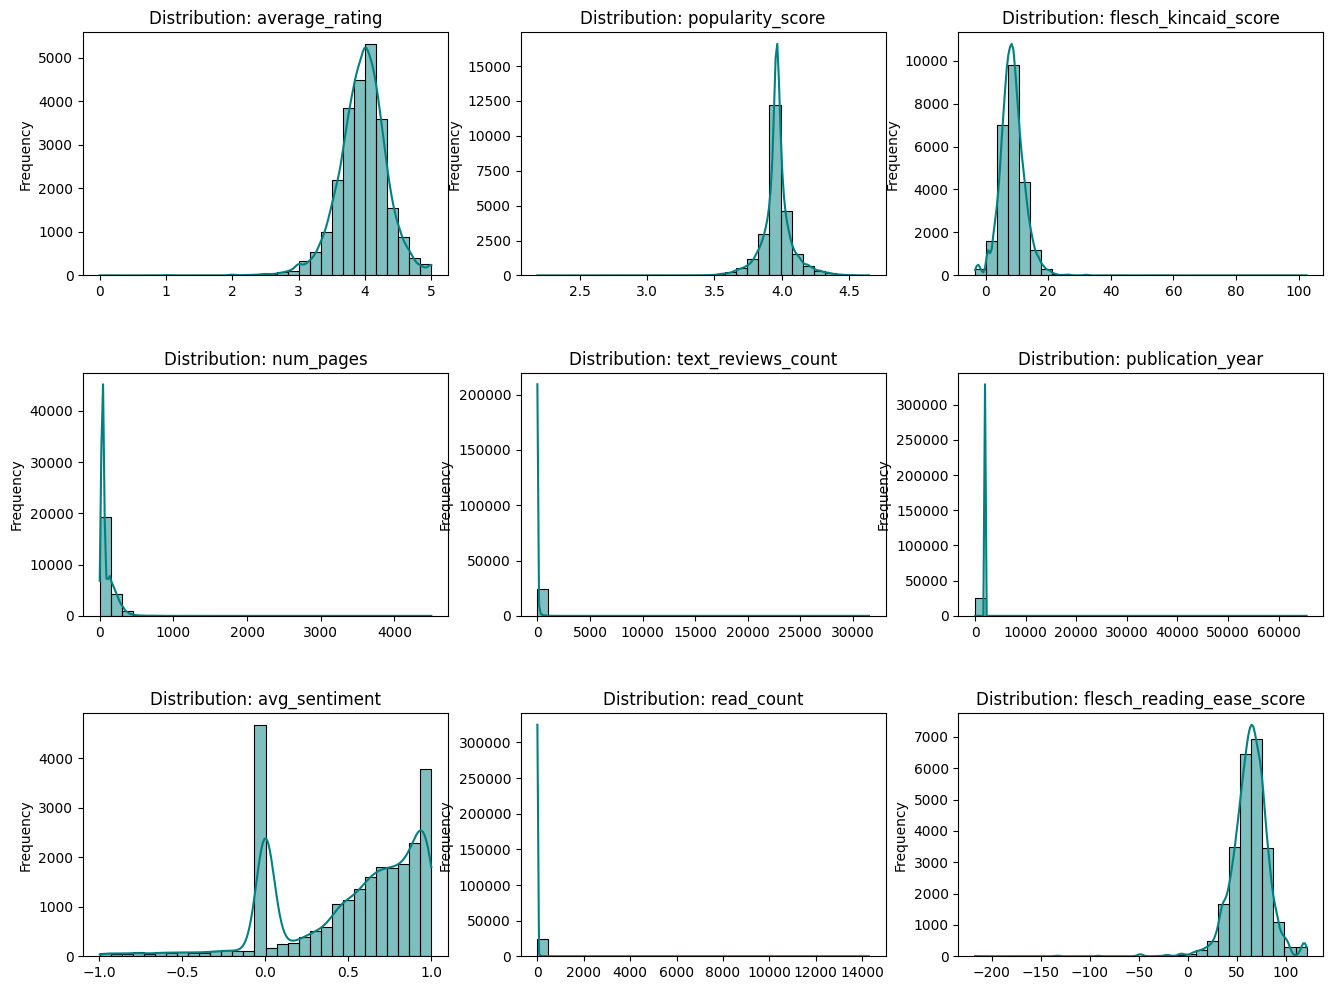

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up a grid for your numerical columns
plt.figure(figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(num_cols):
    ax = plt.subplot(3, 3, i + 1)
    # Use histplot for a clear view of distribution and skewness
    sns.histplot(df[col], kde=True, color='teal', bins=30)
    ax.set_title(f'Distribution: {col}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

In [39]:
skewed_cols = ['text_reviews_count', 'read_count', 'num_pages']

for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])
    
# Update num_cols to use the logs
num_cols = [
    'average_rating', 'popularity_score', 'flesch_kincaid_score', 
    'num_pages_log', 'text_reviews_count_log', 'publication_year', 
    'avg_sentiment', 'read_count_log', 'flesch_reading_ease_score'
]

# to remove year outlier
df = df[(df['publication_year'] <= 2026) & (df['publication_year'] > 1800)]

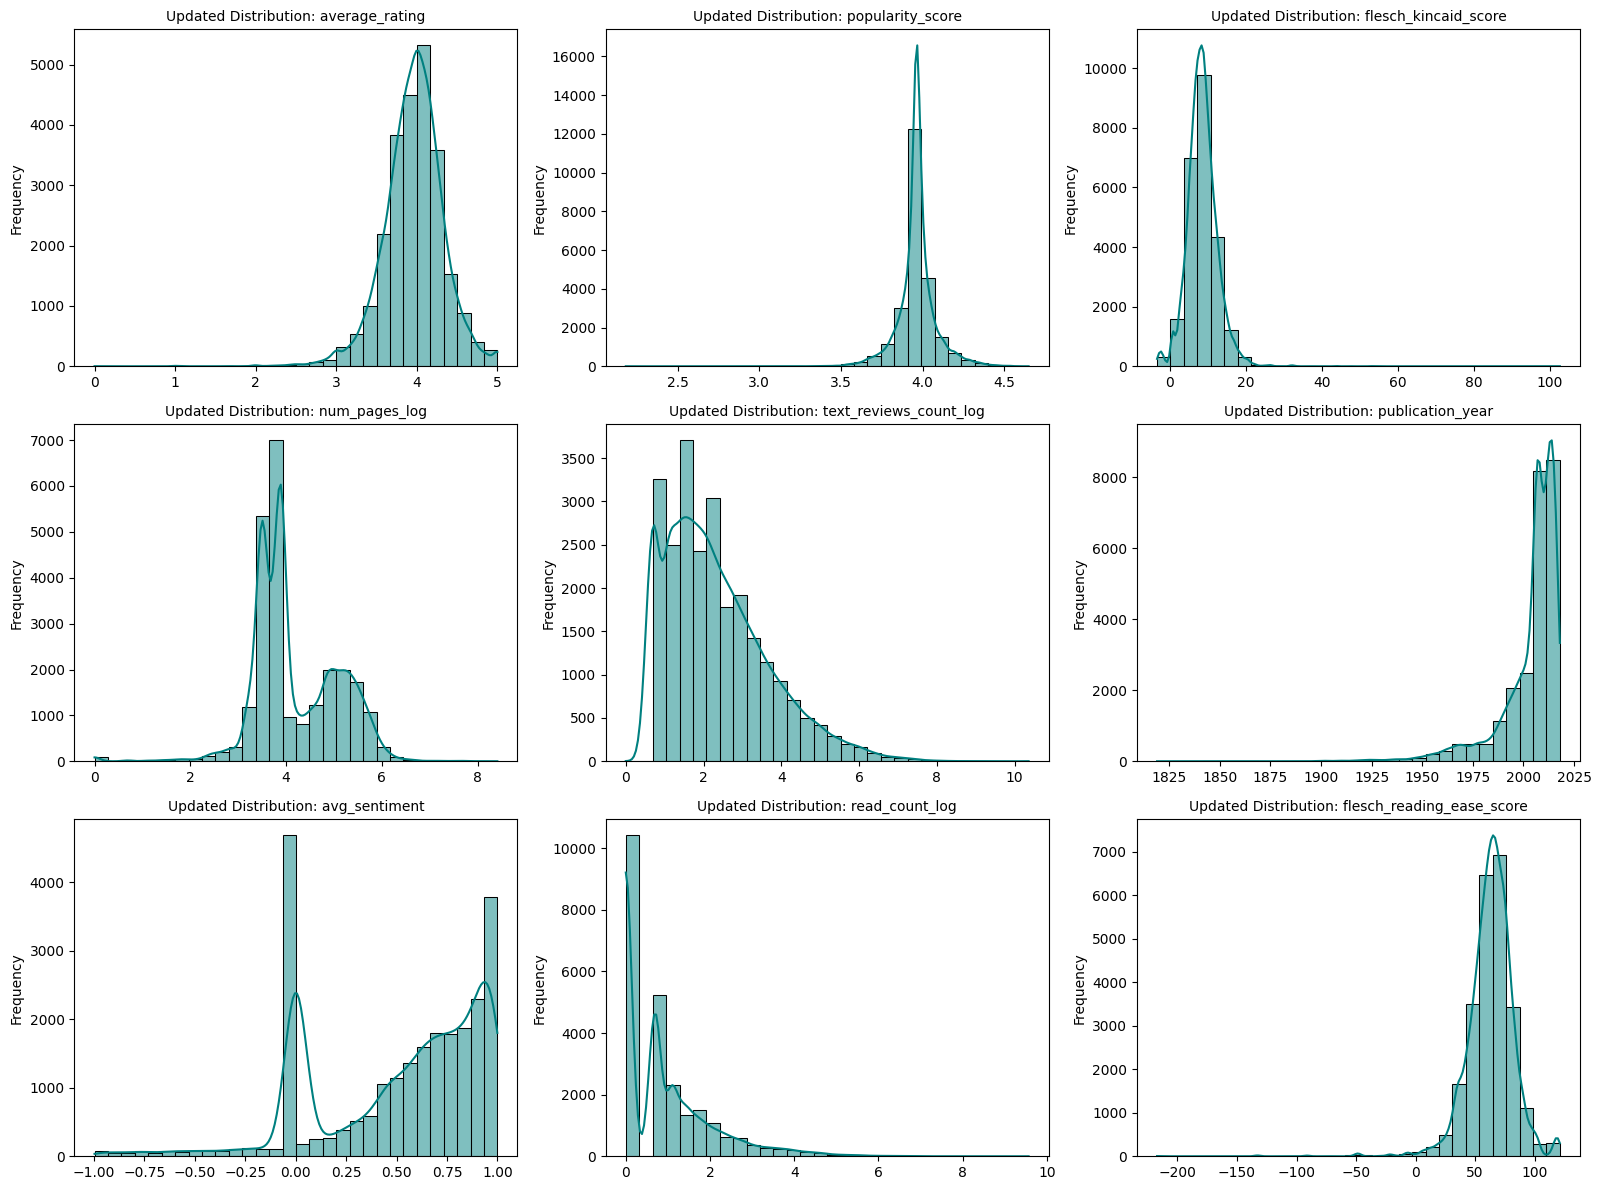

In [40]:
# Visualization of the UPDATED num_cols
plt.figure(figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, col in enumerate(num_cols):
    ax = plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True, color='teal', bins=30)
    ax.set_title(f'Updated Distribution: {col}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [41]:
X_lr= df[num_cols]
y = df['difficulty_level']

X_lr_train, X_lr_test, y_train, y_test = train_test_split(X_lr, y, test_size=0.2, random_state=100)


lr_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols)
])

# Create the Pipeline using the 'preprocessor' 
lr_pipe = Pipeline([
    ('prep', lr_preprocessor), 
    ('clf', LogisticRegression(max_iter=2000, solver='lbfgs'))
])

# Fit the Model
print("Training Logistic Regression...")
lr_pipe.fit(X_lr_train, y_train)

# Evaluate Performance
y_pred = lr_pipe.predict(X_lr_test)

print("\n--- Logistic Regression Performance ---")
print(classification_report(y_test, y_pred))

Training Logistic Regression...

--- Logistic Regression Performance ---
                  precision    recall  f1-score   support

       Difficult       0.97      0.95      0.96       732
            Easy       0.93      0.93      0.93       405
Fairly Difficult       0.94      0.98      0.96       961
     Fairly Easy       0.95      0.97      0.96      1014
        Standard       0.97      0.97      0.97      1366
  Very Confusing       0.99      0.91      0.95       171
       Very Easy       1.00      0.91      0.95       280

        accuracy                           0.96      4929
       macro avg       0.96      0.94      0.95      4929
    weighted avg       0.96      0.96      0.96      4929



In [42]:
coeffs = lr_pipe.named_steps['clf'].coef_
print(coeffs)

[[-3.18156386e-03  1.34912091e-02  2.18989680e+00 -5.95601169e-03
  -5.43115055e-02 -3.97737348e-02 -1.19671238e-02  3.24555482e-02
  -2.53953380e+01]
 [-8.35565449e-02  9.60954810e-03 -1.49114070e+00  6.88134172e-02
   6.84735165e-04  4.10415841e-02  2.23333647e-02  5.11261947e-02
   2.57000000e+01]
 [ 3.44919894e-02 -3.67923353e-02  1.74122627e+00  1.78950901e-02
  -5.68571470e-02  3.88027157e-03  3.91622904e-03  5.35978070e-02
  -1.34922415e+01]
 [ 1.67444406e-03 -5.78603762e-02 -5.26387701e-01  9.91039889e-02
   4.38292899e-02  2.96976643e-02  3.57320341e-02 -4.35831705e-03
   1.37150092e+01]
 [ 1.10449431e-02 -4.22681725e-02  9.84096130e-01  8.70091557e-02
   7.57839669e-04  3.39759124e-02  1.67929386e-02  1.31150609e-02
   8.20437287e-02]
 [ 2.98527102e-02  7.93159801e-02  2.93708815e+00 -1.12980120e-01
  -5.72891654e-02 -1.02979055e-01 -1.69532284e-02 -8.28357925e-02
  -3.25268733e+01]
 [ 9.67402194e-03  3.45041466e-02 -5.83477895e+00 -1.53885520e-01
   1.23185953e-01  3.4157357

In [43]:
# Extract feature names from the preprocessor
feature_names = lr_pipe.named_steps['prep'].get_feature_names_out()

# Get the coefficients (for the first class)
coeffs = lr_pipe.named_steps['clf'].coef_[0]

# Pair them up and sort
importance = dict(zip(feature_names, coeffs))
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

print("Top features increasing difficulty:", sorted_importance[:5])

Top features increasing difficulty: [('num__flesch_kincaid_score', np.float64(2.1898967971978642)), ('num__read_count_log', np.float64(0.03245554821146939)), ('num__popularity_score', np.float64(0.013491209059107705)), ('num__average_rating', np.float64(-0.0031815638608981246)), ('num__num_pages_log', np.float64(-0.005956011690284616))]


In [44]:
print(f"The Intercept (Baseline) is: {lr_pipe.named_steps['clf'].intercept_[0]}")

The Intercept (Baseline) is: 2.255750421310177


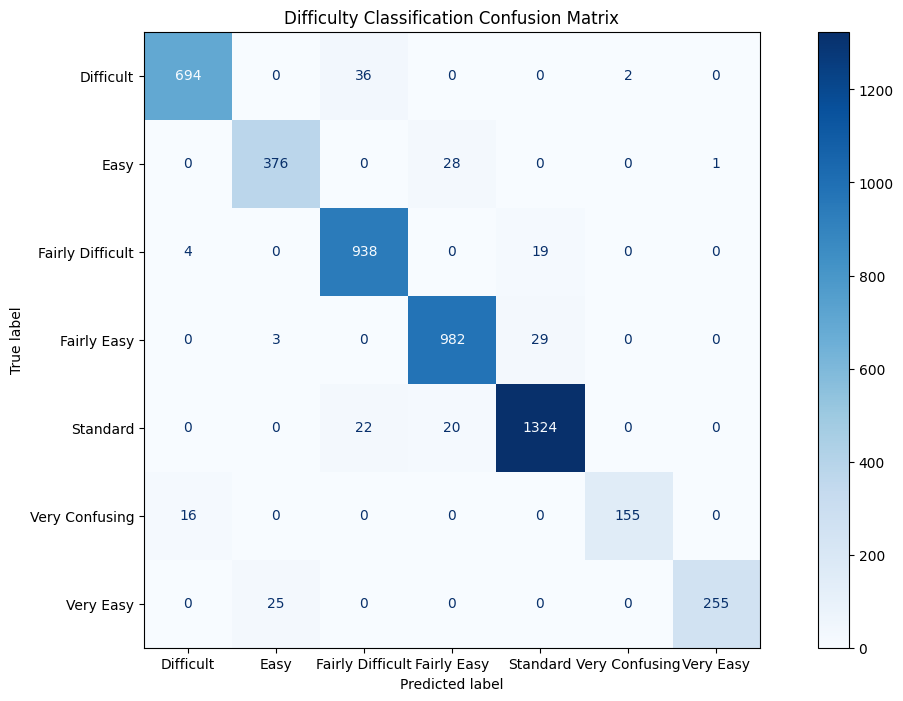

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

#Create confusion matrix plot

fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=lr_pipe.classes_,
    cmap='Blues',
    ax=ax
)

plt.title('Difficulty Classification Confusion Matrix')
plt.show()

In [46]:
X_rf = df[num_cols + [text_col]]
y = df['difficulty_level']

# preprocessing for classification

preprocessor_rf = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('text', TfidfVectorizer(max_features=2000, stop_words=['book']), text_col)
])

X_rf_train, X_rf_test, y_train, y_test = train_test_split(X_rf, y, test_size=0.2, random_state=100)


# Tuned Random Forest

rf_pipe = Pipeline([('prep', preprocessor_rf), ('clf', RandomForestClassifier(random_state=100))])

param_dist = {'clf__n_estimators': [100, 200], 'clf__max_depth': [10, 15, None]}

rf_search = RandomizedSearchCV(rf_pipe, param_distributions=param_dist, n_iter=20, cv=3, n_jobs=-1)

rf_search.fit(X_rf_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=20. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resour

,estimator,Pipeline(step..._state=100))])
,param_distributions,"{'clf__max_depth': [10, 15, ...], 'clf__n_estimators': [100, 200]}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [47]:
# Make predictions using the BEST version found during the search
y_pred = rf_search.predict(X_rf_test)

# Detailed Metrics per Category
print("\n--- Detailed Evaluation Metrics ---")
print(classification_report(y_test, y_pred))


--- Detailed Evaluation Metrics ---
                  precision    recall  f1-score   support

       Difficult       0.90      0.97      0.94       732
            Easy       0.85      0.79      0.82       405
Fairly Difficult       0.98      1.00      0.99       961
     Fairly Easy       0.92      1.00      0.96      1014
        Standard       0.99      1.00      1.00      1366
  Very Confusing       0.99      0.55      0.71       171
       Very Easy       0.99      0.79      0.88       280

        accuracy                           0.95      4929
       macro avg       0.95      0.87      0.90      4929
    weighted avg       0.95      0.95      0.95      4929



In [48]:
# Create Clusters
df['cluster_text'] = df['title'].fillna('') + ' ' + df['clean_description'].fillna('')

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)

tfidf_matrix = vectorizer.fit_transform(df['cluster_text'])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['topic_cluster'] = kmeans.fit_predict(tfidf_matrix)

# print the count of books in each cluster
print("\n--- Books per Cluster ---")
print(df['topic_cluster'].value_counts().sort_index())


--- Books per Cluster ---
topic_cluster
0      444
1     1000
2    16621
3     4941
4     1636
Name: count, dtype: int64


In [49]:
# Get the feature names (words) from the vectorizer
terms = vectorizer.get_feature_names_out()

# Sort the cluster centers to find the most important words
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

print("\n--- Cluster Themes (Top 5 Words) ---")
for i in range(5):
    # Retrieve the top 5 terms for cluster i
    top_words = [terms[ind] for ind in order_centroids[i, :5]]
    print(f"Cluster {i}: {', '.join(top_words)}")



--- Cluster Themes (Top 5 Words) ---
Cluster 0: christmas, santa, holiday, tree, story
Cluster 1: fairy, cat, tale, magic, tales
Cluster 2: friend, new, school, story, adventure
Cluster 3: book, child, story, reader, picture
Cluster 4: little, bear, book, big, golden


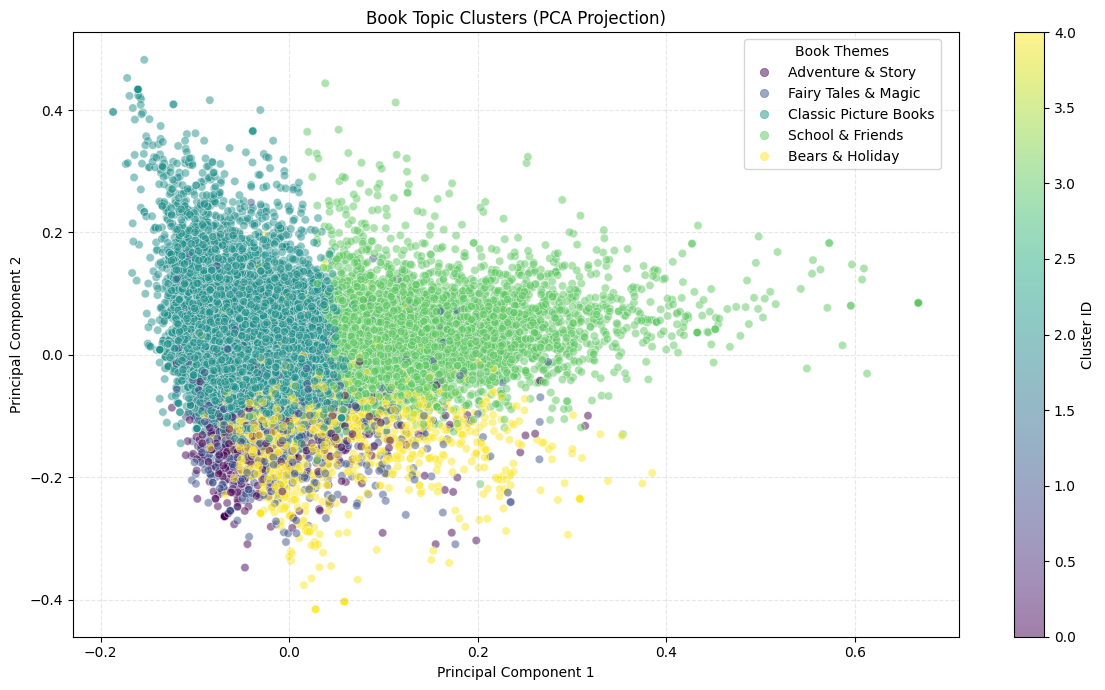

In [50]:
# Initialize PCA (using 2 components for 2D visualization)
pca = PCA(n_components=2, random_state=42)
 
# Transform the data
pca_result = pca.fit_transform(tfidf_matrix.toarray())
 
# Save coordinates for Power BI
df['pca_x_topic_cluster'], df['pca_y_topic_cluster'] = pca_result[:, 0], pca_result[:, 1]
 
# Define the thematic names
cluster_names = [
    "Adventure & Story",
    "Fairy Tales & Magic",
    "Classic Picture Books",
    "School & Friends",
    "Bears & Holiday"
] 
plt.figure(figsize=(12, 7))
 
# 4. Plotting with the PCA coordinates
scatter = plt.scatter(df['pca_x_topic_cluster'], df['pca_y_topic_cluster'], 
                    c=df['topic_cluster'], 
                    cmap='viridis', 
                    alpha=0.5, 
                    edgecolors='w', 
                    linewidth=0.5)
 
# 5. Legend with thematic names
plt.legend(handles=scatter.legend_elements()[0], 
           labels=cluster_names,
           title="Book Themes",
           bbox_to_anchor=(0.75, 1), # Adjusted to move legend fully outside
           loc='upper left')
 
plt.title("Book Topic Clusters (PCA Projection)")
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
# Find the book in the dataframe
# book we want to look up

search_title = "The Teddy Bear Habit"
book_info = df[df['title'].str.contains(search_title, case=False, na=False)]
 
if not book_info.empty:
    # Get the cluster ID and the corresponding name from your list
    cluster_id = int(book_info.iloc[0]['topic_cluster'])
    
    # Use the cluster_names list from the PCA plot
    theme = cluster_names[cluster_id] 
    print(f"Book Found: {book_info.iloc[0]['title']}")
    print(f"Cluster ID: {cluster_id}")
    print(f"Theme: {theme}")
    
    # Show other books in this same cluster
    print(f"\n--- Other books in the '{theme}' cluster ---")
    print(df[df['topic_cluster'] == cluster_id][['title', 'school_level', 'popularity_score']].head(10))
else:
    print(f"Could not find a book matching '{search_title}'")

Book Found: The Teddy Bear Habit
Cluster ID: 4
Theme: Bears & Holiday

--- Other books in the 'Bears & Holiday' cluster ---
                                                 title  school_level  \
7                                 The Teddy Bear Habit    Elementary   
39                                     Charlotte's Web  Kindergarten   
48   Disney's DuckTales: The Hunt for the Giant Pea...    Elementary   
78                             All the Ways I Love You  Kindergarten   
79             The Little Leprechaun who Loved Yellow!  Kindergarten   
86                                        The Flat Man  Kindergarten   
102                             The Little Lame Prince   High School   
123                                       Tumble Tower    Elementary   
126                               The Very Hairy Bear.  Kindergarten   
140                                        The Grizzly    Elementary   

     popularity_score  
7            3.963980  
39           3.984607  
48         

In [52]:
# dictionary to map IDs to the thematic names we defined
cluster_map = {
    0: "Adventure & Story",
    1: "Fairy Tales & Magic",
    2: "Classic Picture Books",
    3: "School & Friends",
    4: "Bears & Holiday"
}

# Map the names to a new column 
df['theme_name'] = df['topic_cluster'].map(cluster_map)

/var/folders/ds/kc8dh42j45v5447mjz7zsrhc0000gn/T/ipykernel_49351/1757242472.py:45: UserWarning: Adding colorbar to a different Figure <Figure size 1200x700 with 3 Axes> than <Figure size 1000x600 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, ticks=[0, 1, 2, 3], label='Cluster ID')


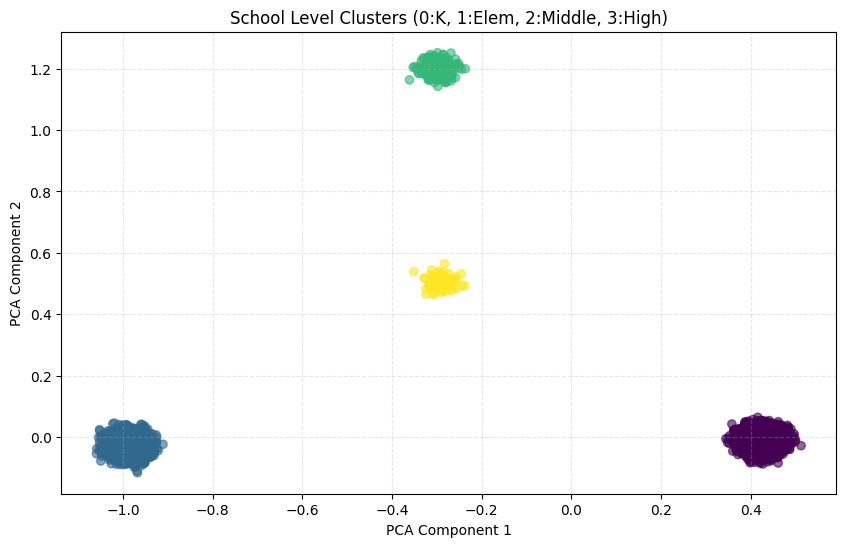

school_level   school_cluster
Elementary     1                  7206
High School    3                    83
Kindergarten   0                 17054
Middle School  2                   299
dtype: int64


In [53]:
#######################################
# Cluster by school_level
#######################################

# Prepare the Data
encoder = OneHotEncoder()
X_school = encoder.fit_transform(df[['school_level']]).toarray()

# Run Clustering
kmeans_school = KMeans(n_clusters=4, random_state=100, n_init=10)

#temporarily store the random IDs
temp_clusters = kmeans_school.fit_predict(X_school)

# looks at what KMeans assigned and re-labels it
cluster_order = {
    "Kindergarten": 0,
    "Elementary": 1,
    "Middle School": 2,
    "High School": 3
}
df['school_cluster'] = df['school_level'].map(cluster_order)

#PCA for Visualization
pca = PCA(n_components=2)
pca_res = pca.fit_transform(X_school)


plt.figure(figsize=(10, 6))

# Create the coordinates with the new new columnnames
df['pca_x_school_cluster'] = pca_res[:, 0] + np.random.normal(0, 0.02, size=len(df))
df['pca_y_school_cluster'] = pca_res[:, 1] + np.random.normal(0, 0.02, size=len(df))

# Plot using the NEW ordered clusters
plt.scatter(df['pca_x_school_cluster'], 
            df['pca_y_school_cluster'], 
            c=df['school_cluster'], 
            cmap='viridis', 
            alpha=0.6)

plt.title("School Level Clusters (0:K, 1:Elem, 2:Middle, 3:High)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, ticks=[0, 1, 2, 3], label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Verify the perfect mapping
print(df.groupby(['school_level', 'school_cluster']).size())

In [54]:
def school_cluster_recommendation(title_query):
    
    # Find the book
    match = df[df['title'].str.contains(title_query, case=False, na=False)]
    
    if match.empty:
        return f"Could not find a book matching '{title_query}'"
    
    # Get the target book's cluster info
    book_row = match.iloc[0]
    target_title = book_row['title']
    target_cluster = book_row['school_cluster']
    target_level = book_row['school_level']

    # Find 5 other books in the same school cluster and sort by popularity_score
    
    similar_books = df[(df['school_cluster'] == target_cluster) & 
                       (df['title'] != target_title)].sort_values(by='popularity_score', ascending=False).head(5)

    print(f"--- Book Found ---")
    print(f"Title: {target_title}")
    print(f"School Level: {target_level} (Cluster {target_cluster})")
    
    print(f"\n--- 5 Other Popular Books in the {target_level} Cluster ---")
    return similar_books[['title', 'popularity_score', 'difficulty_level','school_level']]


school_cluster_recommendation("The Saturdays")

--- Book Found ---
Title: The Saturdays
School Level: Elementary (Cluster 1)

--- 5 Other Popular Books in the Elementary Cluster ---


,title,popularity_score,difficulty_level,school_level
16931,I Dissent: Ruth Bader Ginsburg Makes Her Mark,4.612745,Difficult,Elementary
18481,Abol Tabol: The Nonsense World of Sukumar Ray,4.570103,Very Confusing,Elementary
7748,Let Me Hold You Longer,4.560071,Difficult,Elementary
10111,Nutshell Library,4.536422,Difficult,Elementary
13118,"The Anne Stories (Anne of Green Gables, #1-3, ...",4.524655,Fairly Difficult,Elementary


In [55]:
school_cluster_recommendation("Charlotte's Web")

--- Book Found ---
Title: Charlotte's Web
School Level: Kindergarten (Cluster 0)

--- 5 Other Popular Books in the Kindergarten Cluster ---


,title,popularity_score,difficulty_level,school_level
10226,Children's Songbook,4.647651,Very Easy,Kindergarten
24259,"We are in a Book! (Elephant & Piggie, #13)",4.572503,Fairly Difficult,Kindergarten
20916,"Worlds Collide (The Land of Stories, #6)",4.539165,Standard,Kindergarten
14084,"School Daze (Diary of a Minecraft Zombie, #5)",4.539062,Fairly Easy,Kindergarten
10540,Zombie Family Reunion (Diary of a Minecraft Zo...,4.532375,Fairly Difficult,Kindergarten


In [56]:
df.head()

,book_id,title,description,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,language_code,image_url,...,read_count_log,num_pages_log,cluster_text,topic_cluster,pca_x_topic_cluster,pca_y_topic_cluster,theme_name,school_cluster,pca_x_school_cluster,pca_y_school_cluster
0,89378,Dog Heaven,In Newbery Medalist Cynthia Rylant's classic b...,4.43,1331,193,40.0,1995.0,eng,https://images.gr-assets.com/books/1360057676m...,...,2.70805,3.713572,Dog Heaven newbery medalist cynthia rylants cl...,3,0.045262,0.044891,School & Friends,1,-0.986701,-0.020483
1,8037411,The Saturdays,Meet the Melendys! The four Melendy children l...,4.14,45,7,192.0,1941.0,eng,https://images.gr-assets.com/books/1312143418m...,...,0.00000,5.262690,The Saturdays meet melendys four melendy child...,2,-0.006462,0.050230,Classic Picture Books,1,-0.977788,-0.038533
2,34680604,Sir Chocolate and the sugar dough bees story a...,A greedy snail damages the flower fields and t...,4.55,11,9,48.0,2017.0,eng,https://images.gr-assets.com/books/1490458674m...,...,0.00000,3.891820,Sir Chocolate and the sugar dough bees story a...,1,-0.041210,-0.073518,Fairy Tales & Magic,0,0.415338,-0.014340
3,30199811,Only One,"A novel counting book, centered around a count...",3.59,2,2,48.0,1993.0,eng,https://images.gr-assets.com/books/1497527097m...,...,0.00000,3.891820,Only One novel counting book centered around c...,3,0.124688,0.063175,School & Friends,1,-0.992376,-0.058819
4,8307481,The Blue Cat of Castle Town,The Blue Cat of Castle Town,3.96,3,2,48.0,1949.0,eng,https://s.gr-assets.com/assets/nophoto/book/11...,...,0.00000,3.891820,The Blue Cat of Castle Town blue cat castle town,1,-0.084155,-0.064069,Fairy Tales & Magic,0,0.443214,-0.037261


In [57]:
####################################################
# Combine both cluster types to give reommendation
###################################################

def double_match_recommender(title_query, n=5):
    
    # Find the target book
    match = df[df['title'].str.contains(title_query, case=False, na=False)]
    if match.empty: return "Book not found."
    
    book_row = match.iloc[0]
    s_cluster = book_row['school_cluster']
    t_cluster = book_row['topic_cluster'] 
    theme = book_row['theme_name']
    level = book_row['school_level']

    # Filter for BOTH clusters
    # Then find books in the same Grade AND the same Topic
    results = df[(df['school_cluster'] == s_cluster) & 
                 (df['topic_cluster'] == t_cluster) & 
                 (df['title'] != book_row['title'])]
    
    # Sort by popularity to get the "Best" recommendations
    final_list = results.sort_values(by='popularity_score', ascending=False).head(n)
    
    print(f"Recommendations for '{book_row['title']}' book reader")
    print(f"Criteria: {level} books about {theme}\n")
    
    return final_list[['title', 'popularity_score', 'difficulty_level','school_level']]

double_match_recommender("The Saturdays")

Recommendations for 'The Saturdays' book reader
Criteria: Elementary books about Classic Picture Books



,title,popularity_score,difficulty_level,school_level
4451,Bird of the Soul,4.521856,Standard,Elementary
7874,"Yellowfang's Secret (Warriors Super Edition, #5)",4.520037,Fairly Difficult,Elementary
8701,"An Author's Odyssey (The Land of Stories, #5)",4.458869,Fairly Difficult,Elementary
10808,The Complete Adventures of Peter Rabbit,4.454631,Fairly Difficult,Elementary
12808,Percy Jackson and the Olympians Boxed Set,4.453189,Fairly Difficult,Elementary


In [58]:
double_match_recommender("Charlotte's Web")

Recommendations for 'Charlotte's Web' book reader
Criteria: Kindergarten books about Bears & Holiday



,title,popularity_score,difficulty_level,school_level
6232,"The World of Winnie-the-Pooh (Winnie-the-Pooh,...",4.427917,Standard,Kindergarten
16164,I Want My Hat Back,4.386726,Standard,Kindergarten
7698,"The Little Mermaid (Disney Princess, 2)",4.360557,Fairly Difficult,Kindergarten
18048,The Fourteen Bears in Summer and Winter,4.356839,Fairly Easy,Kindergarten
19897,My Goodnight Book,4.329953,Easy,Kindergarten


In [59]:

#Vectorizing entire dataset
tfidf = TfidfVectorizer(stop_words='english')

# Combine features for content-based filtering
tfidf_content = df['title'].fillna('') + ' ' + df['clean_description'].fillna('')
tfidf_matrix = tfidf.fit_transform(tfidf_content)

# Pre-scale popularity
scaler = MinMaxScaler()
df['pop_norm'] = scaler.fit_transform(df[['popularity_score']])


def book_recommender(title_query, n=10):
    
    # Find the target book
    
    match = df[df['title'].str.contains(title_query, case=False, na=False, regex=False)]
    if match.empty: return "Book not found."
    
    # Get the first match's specific row and index
    target_idx = match.index[0]
    target_row = df.iloc[df.index.get_loc(target_idx)]
    
    target_cluster = target_row['school_cluster']
    target_sentiment = target_row['avg_sentiment']

    pool = df.copy()
    
    target_pos = df.index.get_loc(target_idx)
    sim_scores = linear_kernel(tfidf_matrix[target_pos], tfidf_matrix).flatten()


    # Final Hybrid Scoring
    pool['sim_score'] = sim_scores
    pool['school_match'] = (pool['school_cluster'] == target_cluster).astype(int)
    pool['sent_match'] = 1 - abs(pool['avg_sentiment'] - target_sentiment)

    # 60% Content Similarity, 15% Popularity, 10% Emotional Vib and 15% school_match
    pool['final_score'] = (
        (pool['sim_score'] * 0.60) + 
        (pool['school_match'] * 0.15) + 
        (pool['pop_norm'] * 0.15) + 
        (pool['sent_match'] * 0.10)
    )

    return pool[pool.index != target_idx].sort_values(by='final_score', ascending=False).head(n)

# Test run
print(f"Top 10 Hybrid Recommendations for '{search_title}':")
book_recommender("The Teddy Bear Habit")[['title', 'school_level', 'popularity_score', 'final_score']]

Top 10 Hybrid Recommendations for 'The Teddy Bear Habit':


,title,school_level,popularity_score,final_score
5982,"Cheer Up Your Teddy Bear, Emily Brown!",Elementary,3.957773,0.449091
20571,The Berenstain Bears and the Bad Habit,Elementary,3.965694,0.430096
4719,Teddy the Bear,Elementary,3.930073,0.425439
15844,"The Tin Woodman of Oz (Oz, #12)",Elementary,3.955060,0.417171
23685,Teddy Bears in Monsterland,Elementary,3.965694,0.414900
11119,The Berenstain Bears Save Christmas (Berenstai...,Elementary,3.953498,0.403237
20137,The Boy with Two Shadows,Elementary,3.956569,0.384883
17721,"Rest, Play, Grow: Making Sense of Preschoolers",Elementary,4.001695,0.379497
10948,Starting with Melodie,Elementary,3.893614,0.377590
18781,"The Silver Horn (Eaglesmount Trilogy, #1)",Elementary,3.955569,0.376726


In [60]:
book_recommender("Measly Medicine")[['title', 'school_level', 'popularity_score', 'final_score']]

,title,school_level,popularity_score,final_score
10614,From the Notebooks of a Middle School Princess...,Middle School,3.953091,0.379983
13318,The Annotated Hans Christian Andersen,Middle School,4.385529,0.378442
15163,The Mysterious Benedict Society Collection (Th...,Middle School,4.473951,0.374380
10499,The World Treasury of Children's Literature: B...,Middle School,4.079986,0.367223
20362,Told Under the Magic Umbrella,Middle School,3.975160,0.362429
7008,"All About China: Stories, Songs, Crafts and Mo...",Middle School,4.008857,0.361414
18351,The Sheep of the Lal Bagh,Middle School,4.029371,0.361125
4299,A Day to Remember,Middle School,3.929623,0.359497
4669,Jurassic Classics: The Presidential Masters of...,Middle School,3.976482,0.359232
13084,The Boy Who Drew Cats and Other Japanese Fairy...,Middle School,3.965262,0.357748


In [61]:
book_recommender("The Saturdays")[['title', 'school_level', 'popularity_score', 'final_score']]

,title,school_level,popularity_score,final_score
12885,"The Four-Story Mistake (The Melendy Family, #2)",Kindergarten,4.247757,0.437588
18475,I Love Saturdays y Domingos,Elementary,3.990828,0.425935
13700,Adventure Series Set (Books 1-8),Elementary,4.125246,0.408887
23589,Enid Blyton Adventure Series 8 Books Set Colle...,Elementary,3.985554,0.399360
15140,Oliver & Company,Elementary,3.954000,0.397284
13118,"The Anne Stories (Anne of Green Gables, #1-3, ...",Elementary,4.524655,0.393604
4451,Bird of the Soul,Elementary,4.521856,0.392119
7423,The Princess Fables,Elementary,4.220761,0.391334
4705,The Half Upon a Time Trilogy: Half Upon a Time...,Elementary,4.345859,0.391281
22779,Complete Fairy Tales,Elementary,4.055746,0.390906


In [62]:
###############################
# Sample test set
###############################
test_books = df.sample(400, random_state=100)

###########################################
# Relevance function 
###########################################
def get_relevant(book_row):
    return df[
        (df['school_cluster'] == book_row['school_cluster'])&
        (df['book_id'] != book_row['book_id'])
    ]

#########################
# Evaluation Metrics
#########################
def precision_at_k(recommended, relevant_set, k=10):
    recommended_k = recommended.head(k)['book_id']
    return len(set(recommended_k) & set(relevant_set)) / k


def recall_at_k(recommended, relevant_set, k=10):
    recommended_k = recommended.head(k)['book_id']
    return len(set(recommended_k) & set(relevant_set)) / len(relevant_set) if len(relevant_set) > 0 else 0


def ndcg_at_k(recommended, relevant_set, k=10):
    rec_k = recommended.head(k)['book_id'].values

    dcg = 0.0
    for i, item in enumerate(rec_k):
        if item in relevant_set:
            dcg += 1 / np.log2(i + 2)

    ideal_hits = min(len(relevant_set), k)
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg if idcg > 0 else 0


################################
# Evaluation loop
################################
k = 10
precisions = []
recalls = []
ndcgs = []

failed = 0

for _, row in test_books.iterrows():
    query_title = row['title']

    recs = book_recommender(query_title, n=k)

    # skip failed matches
    if isinstance(recs, str):
        failed += 1
        continue

    relevant = get_relevant(row)['book_id'].tolist()

    # skip empty relevance sets
    if len(relevant) == 0:
        continue

    precisions.append(precision_at_k(recs, relevant, k))
    recalls.append(recall_at_k(recs, relevant, k))
    ndcgs.append(ndcg_at_k(recs, relevant, k))


###############################
# Final evaluation metrics
###############################

if len(precisions) == 0:
    print("No valid evaluations generated.")
    print("Failed queries:", failed)
else:
    print("Failed queries:", failed)
    print("Mean Precision@10:", np.mean(precisions))
    print("Mean Recall@10:", np.mean(recalls))
    print("Mean NDCG@10:", np.mean(ndcgs))

Failed queries: 0
Mean Precision@10: 0.956
Mean Recall@10: 0.0015534918458002982
Mean NDCG@10: 0.9524852152881427


In [63]:
# --- FINAL EXPORT FOR POWER BI ---

# Select the optimized columns for visualization
power_bi_df = df[[
    'book_id', 'title','clean_description', 'description' ,'school_level', 'theme_name','school_cluster','flesch_reading_ease_score',
    'difficulty_level','image_url','average_rating', 'popularity_score', 'avg_sentiment','review_count','ratings_count',
    'num_pages_log','text_reviews_count_log','read_count'
]]

## Save the final CSV
#power_bi_df.to_csv("final.csv", index=False)

power_bi_df.head()

,book_id,title,clean_description,description,school_level,theme_name,school_cluster,flesch_reading_ease_score,difficulty_level,image_url,average_rating,popularity_score,avg_sentiment,review_count,ratings_count,num_pages_log,text_reviews_count_log,read_count
0,89378,Dog Heaven,newbery medalist cynthia rylants classic bests...,In Newbery Medalist Cynthia Rylant's classic b...,Elementary,School & Friends,1,48.493571,Difficult,https://images.gr-assets.com/books/1360057676m...,4.43,4.383599,0.673271,28.0,1331,3.713572,5.267858,14.0
1,8037411,The Saturdays,meet melendys four melendy child live father c...,Meet the Melendys! The four Melendy children l...,Elementary,Classic Picture Books,1,45.998433,Difficult,https://images.gr-assets.com/books/1312143418m...,4.14,4.003849,0.995500,1.0,45,5.262690,2.079442,0.0
2,34680604,Sir Chocolate and the sugar dough bees story a...,greedy snail damage flower field fondant bee d...,A greedy snail damages the flower fields and t...,Kindergarten,Fairy Tales & Magic,0,69.463913,Standard,https://images.gr-assets.com/books/1490458674m...,4.55,4.003092,0.906000,1.0,11,3.891820,2.302585,0.0
3,30199811,Only One,novel counting book centered around county fai...,"A novel counting book, centered around a count...",Elementary,School & Friends,1,35.296667,Difficult,https://images.gr-assets.com/books/1497527097m...,3.59,3.957017,0.680800,1.0,2,3.891820,1.098612,0.0
4,8307481,The Blue Cat of Castle Town,blue cat castle town,The Blue Cat of Castle Town,Kindergarten,Fairy Tales & Magic,0,102.045000,Very Easy,https://s.gr-assets.com/assets/nophoto/book/11...,3.96,3.961987,0.983000,2.0,3,3.891820,1.098612,0.0
